In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
df = pd.read_csv(r"C:\Users\M\Downloads\Titanic-Dataset (1).csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Task 1: Data Quality Issues

In [9]:
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


np.int64(0)

In Task 1, I checked the quality of the dataset.

First, I looked for missing values. I found that the Age column has missing values. The Cabin column has many missing values. The Embarked column has a few missing values. Missing data can cause problems in analysis, so it must be handled.

Second, I checked if there are duplicate rows. I found that there are no duplicate rows in the dataset.

Third, I noticed that some columns contain text, such as Name, Ticket, and Cabin. These columns cannot be directly used in machine learning models because models need numbers. So, they may need encoding or removal later.

Task 2: Handling Missing Values

In [10]:
median_age = df["Age"].median()
df["Age"] = df["Age"].fillna(median_age)
df["Age"].isnull().sum()

np.int64(0)

In Task 2, I handled the missing values in the Age column.

I decided to use the median to fill the missing values. I chose the median because it is not affected by extreme values (outliers). This makes it a good choice when the data is not evenly distributed.

After filling the missing values, the Age column no longer has missing data.

Task 3: Detect and Handle Outliers (IQR Method)

Before applying the IQR

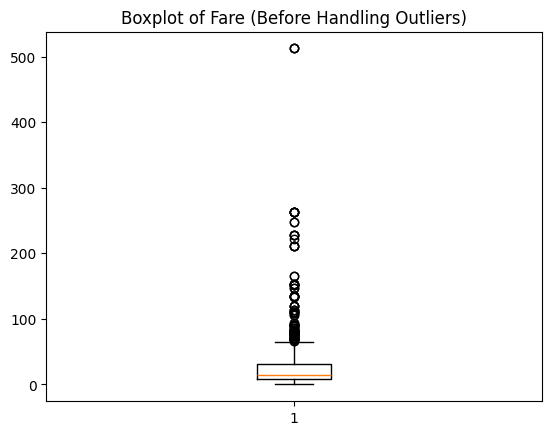

In [21]:
import matplotlib.pyplot as plt

plt.boxplot(df["Fare"])
plt.title("Boxplot of Fare (Before Handling Outliers)")
plt.show()

In [22]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df["Fare"] < lower) | (df["Fare"] > upper)]
outliers.shape[0]
df["Fare"] = df["Fare"].clip(lower, upper)

After applying

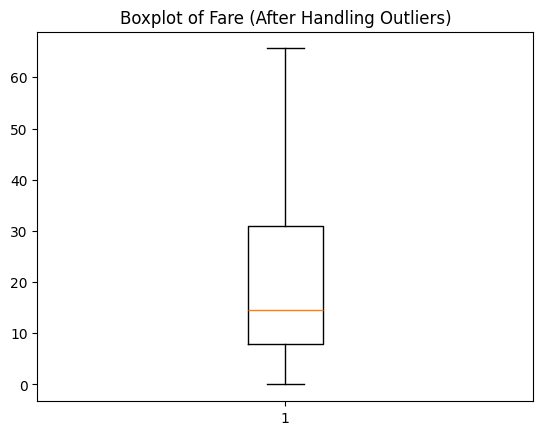

In [23]:
plt.boxplot(df["Fare"])
plt.title("Boxplot of Fare (After Handling Outliers)")
plt.show()

In Task 3, I detected outliers in the Fare column using the IQR method.

First, I calculated Q1 (25th percentile) and Q3 (75th percentile). Then, I calculated the IQR by subtracting Q1 from Q3. After that, I computed the lower and upper bounds using the IQR formula.

From the boxplot and calculations, I found that there were outliers in the Fare column. Instead of deleting these values, I used capping. This means I replaced extreme values with the lower or upper limit.

This method keeps all the data while reducing the effect of extreme values. It makes the dataset more balanced without losing too much information.

Task 4: Normalization

In [12]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
num_cols = ["Age", "Fare", "SibSp", "Parch"]
minmax = MinMaxScaler()
df_minmax = minmax.fit_transform(df[num_cols])
zscaler = StandardScaler()
df_zscore = zscaler.fit_transform(df[num_cols])

In Task 4, I normalized the numerical features.

First, I used Min-Max scaling. This method changes values to be between 0 and 1.

Then, I used Z-score standardization. This method makes the mean equal to 0 and the standard deviation equal to 1.

Z-score is important before applying PCA because PCA is affected by scale differences.

Task 5: PCA

In [14]:
from sklearn.decomposition import PCA
import numpy as np
pca = PCA()
pca.fit(df_zscore)
pca.explained_variance_ratio_
np.cumsum(pca.explained_variance_ratio_)

array([0.43423382, 0.71801439, 0.87056508, 1.        ])

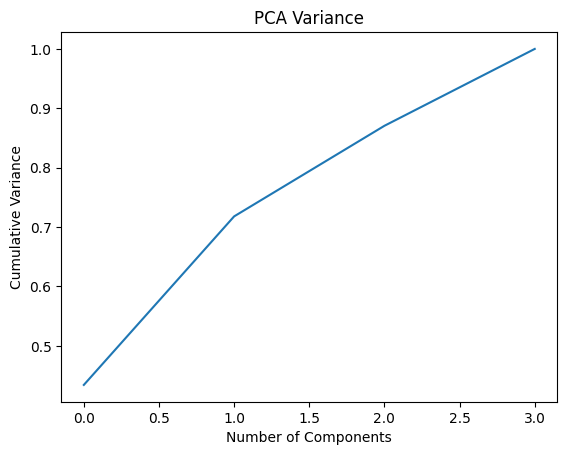

In [19]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("PCA Variance")
plt.show()

In Task 5, I applied PCA to reduce the number of features.

I used PCA on the standardized data. From the graph, we can see that the first principal component explains the largest amount of variance. The first two components explain about 71% of the variance, and the first three components explain about 87%.

This means that most of the important information is contained in the first two or three components. So, we can reduce the number of features while keeping most of the important information.

In conclusion, PCA helps reduce dimensionality without losing too much data information.